**Dataset:** `data/titanic.csv` (891 passengers). The placement columns of the original notebook are mapped to Titanic columns as described below.

Mapping: `CGPA` → `Pclass`, `Salary Package` → `Fare`, 'placed students with salary > 0' → passengers with `Fare > 0`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

In [2]:
#Read the dataset
df = pd.read_csv("/Users/divyasaisomana/placement prediction system/data/titanic.csv")

print("Dataset shape:", df.shape)
display(df.head())

Dataset shape: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## Select X and y from dataset

In [3]:
X = df[["Pclass"]]
y = df["Fare"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (891, 1)
y shape: (891,)


## Use passengers with a positive fare only

There are 876 passengers with Fare > 0 (the 15 zero-fare records are excluded, mirroring the 'placed passengers with salary > 0' filter of the original notebook).

In [4]:
placed_df = df[df["Fare"] > 0].copy()

print("Passengers with Fare > 0:", len(placed_df))

Passengers with Fare > 0: 876


In [5]:
X = placed_df[["Pclass"]]
y = placed_df["Fare"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (876, 1)
y shape: (876,)


## Split the dataset into training and testing sets

In [6]:

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training samples:", len(X_train))
print("Testing samples :", len(X_test))

Training samples: 700
Testing samples : 176


In [7]:
model = LinearRegression()

#Traing the model with training data
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[-34.23]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['Pclass']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,112.4
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)


In [8]:
print("Intercept:", model.intercept_)
print("Coefficient:", model.coef_[0])

Intercept: 112.38075507628373
Coefficient: -34.23377366549126


In [9]:
#Predicting the fare for training data

y_train_pred = model.predict(X_train)

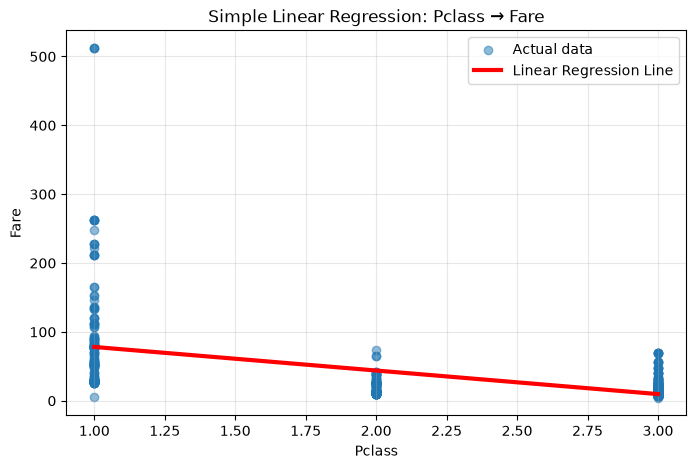

In [10]:
plt.figure(figsize=(8, 5))
plt.scatter(
    X_train["Pclass"],
    y_train,
    alpha=0.5,
    label="Actual data"
)

plt.plot(
    X_train["Pclass"],
    y_train_pred,
    color="red",
    linewidth=3,
    label="Linear Regression Line"
)

plt.xlabel("Pclass")
plt.ylabel("Fare")
plt.title("Simple Linear Regression: Pclass → Fare")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Here the red line goes downward from left to right.

That means:

1. As Pclass increases (1 = first class, 3 = third class), the model predicts a lower fare on average.

2. So there is a negative relationship between Pclass and predicted fare.

The blue dots are the actual fares. The red line is the fare predicted using only Pclass. Fares within each class vary widely (especially first class), so Pclass alone cannot fully explain fare variation. This is why we later move from Simple Linear Regression to Multiple Linear Regression by adding other relevant features.

In [11]:
#predicting the fare for testing data
y_test_pred = model.predict(X_test)

In [12]:
mse = mean_squared_error(y_test, y_test_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_test_pred)
r2 = r2_score(y_test, y_test_pred)

print("MSE :", mse)
print("RMSE:", rmse)
print("MAE :", mae)
print("R²  :", r2)

MSE : 1272.7821522136528
RMSE: 35.67607254468536
MAE : 22.907900189779514
R²  : 0.3712876265781946


In [13]:
## Give a new passenger's Pclass
new_cgpa = 2.0   # fixed sample value (input() cannot be used in a non-interactive run)

## Predict fare

predicted_fare = model.predict([[new_cgpa]])[0]

print(f"Predicted Fare: {predicted_fare:.2f}")

Predicted Fare: 43.91


/Users/divyasaisomana/placement prediction system/.MLvenv/lib/python3.14/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
